In [1]:
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

I0000 00:00:1781384696.449830    1547 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781384697.012464    1547 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781384699.249944    1547 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import json

# caminho para o dataset
path = 'archive/Sarcasm_Headlines_Dataset.json'

# listas para guardas as informações
sentences = []
labels = []

# abrindo o dataset
with open(path, 'r') as f:
    for line in f:
        
        # para cada dicionario, adiciona os itens na lista

        item = json.loads(line)
        sentences.append(item['headline'])
        labels.append(item['is_sarcastic'])

In [3]:
# variaveis da tokenizacao
vocab_size = 10000
embedding_dim = 16
max_length = 100
trunc_type='post'
padding_type='post'
oov_tok = "<OOV>"
training_size = 20000

In [4]:
# separando os dados de treino e teste
training_sentences = sentences[0:training_size]
testing_sentences = sentences[training_size:]
training_labels = labels[0:training_size]
testing_labels = labels[training_size:]

In [5]:
# criando o tokenizador
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(training_sentences)

# mapeamento das palavras
word_index = tokenizer.word_index

# criando as sequencias de treino e teste
training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [6]:
import numpy as np

# convertendo para numpy
training_padded = np.array(training_padded)
training_labels = np.array(training_labels)
testing_padded = np.array(testing_padded)
testing_labels = np.array(testing_labels)

In [7]:
# criando a rede neural
model = tensorflow.keras.models.Sequential()

# camadas do modelo
model.add(tensorflow.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length))
model.add(tensorflow.keras.layers.GlobalAveragePooling1D())
model.add(tensorflow.keras.layers.Dense(24, activation='relu'))
model.add(tensorflow.keras.layers.Dense(1, activation='sigmoid'))

# compilando
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/home/liperasz/miniconda3/envs/card-23/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1781384700.908793    1547 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
# sumario
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# epocas de treinamento
num_epochs = 30

# treinamento
history = model.fit(training_padded, training_labels, epochs=num_epochs, validation_data=(testing_padded, testing_labels), verbose=2)

Epoch 1/30
625/625 - 3s - 5ms/step - accuracy: 0.5755 - loss: 0.6748 - val_accuracy: 0.7181 - val_loss: 0.6279
Epoch 2/30
625/625 - 2s - 3ms/step - accuracy: 0.7567 - loss: 0.5220 - val_accuracy: 0.7755 - val_loss: 0.4672
Epoch 3/30
625/625 - 2s - 3ms/step - accuracy: 0.8217 - loss: 0.4026 - val_accuracy: 0.8332 - val_loss: 0.3950
Epoch 4/30
625/625 - 2s - 3ms/step - accuracy: 0.8516 - loss: 0.3485 - val_accuracy: 0.7971 - val_loss: 0.4204
Epoch 5/30
625/625 - 2s - 3ms/step - accuracy: 0.8726 - loss: 0.3100 - val_accuracy: 0.8375 - val_loss: 0.3703
Epoch 6/30
625/625 - 2s - 3ms/step - accuracy: 0.8802 - loss: 0.2901 - val_accuracy: 0.8539 - val_loss: 0.3487
Epoch 7/30
625/625 - 2s - 3ms/step - accuracy: 0.8945 - loss: 0.2576 - val_accuracy: 0.8493 - val_loss: 0.3510
Epoch 8/30
625/625 - 2s - 3ms/step - accuracy: 0.9017 - loss: 0.2412 - val_accuracy: 0.8518 - val_loss: 0.3463
Epoch 9/30
625/625 - 2s - 3ms/step - accuracy: 0.9139 - loss: 0.2195 - val_accuracy: 0.8328 - val_loss: 0.3935
E

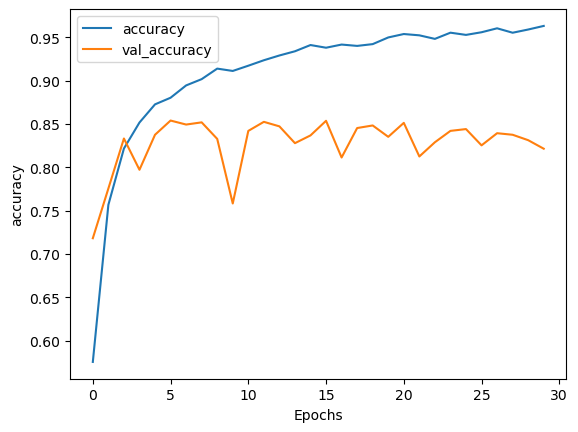

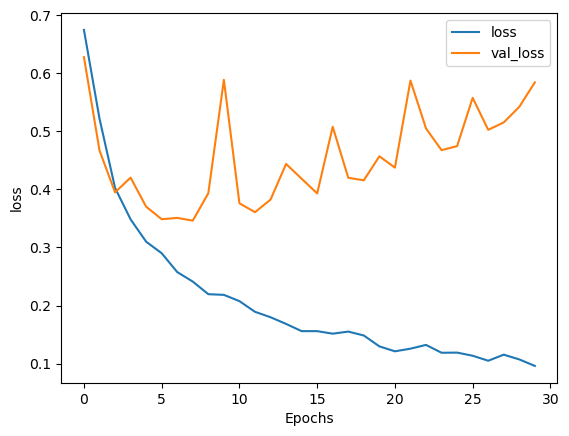

In [10]:
import matplotlib.pyplot as plt

# funcao para plotar o grafico
def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_' +string])
    plt.xlabel('Epochs')
    plt.ylabel(string)
    plt.legend([string, 'val_' +string])
    plt.show()

# mostrando so graficos de historico
plot_graphs(history, 'accuracy')
plot_graphs(history, 'loss')

In [ ]:
# vendo exemplo de resposta
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_sentence(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

print(decode_sentence(training_padded[0]))
print(training_sentences[2])
print(labels[2])

former <OOV> store clerk sues over secret 'black <OOV> for minority shoppers ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?
mom starting to fear son's web series closest thing she will have to grandchild
1


In [ ]:
# vendo os pesos das primeiras camadas
e = model.layers[0]
weights = e.get_weights()[0]
print(weights.shape)

(10000, 16)
